# Visualization with Seaborn

- Matplotlib is the foundational plotting library in Python and underpins much of the ecosystem. As a low-level, general-purpose tool, it offers fine control but can feel verbose for everyday statistical graphics. 

- Seaborn builds on Matplotlib with modern style and color defaults, concise high-level plotting functions, and tight Pandas integration. In practice, you can produce attractive, label-aware figures with much less code while still dropping down to Matplotlib for fine control. 

- Seaborn also includes quick routines for statistical exploration—distributions, relationships, and categorical patterns—and basic model-fitting and diagnostic plots.

By convention, Seaborn is often imported as `sns`:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %pip install seaborn
import seaborn as sns

Next, we’ll explore a few of Seaborn’s built-in datasets and plot types. Everything we do could be replicated with raw Matplotlib. Seaborn simply wraps those calls under the hood, but its higher-level API makes the workflow far more convenient. The built-in plot types introduced here are:

- **Histogram**
- **KDE**
- **Density**
- **Scatter**
- **Pair**
- **Categorical**: Box plot and Bar plot
- **Joint Plots**: Hex plot and regression plot
- **Faceted Plots**

## Seaborn Datasets

Seaborn comes with several datasets that are commonly used for learning data science. We will generate a dataset ourselves first and then use the two built-in datasets in this section.

### Iris

The **Iris dataset**, introduced by Ronald A. Fisher in 1936, is one of the most well-known datasets in statistics and machine learning. It is often used for testing classification and visualization techniques. It contains measurements of three species of iris flowers: *Setosa*, *Versicolor*, and *Virginica*. The features of the iris dataset include:

| Feature | Description | Units |
|----------|--------------|--------|
| **sepal_length** | Length of the outer part of the flower | cm |
| **sepal_width** | Width of the outer part | cm |
| **petal_length** | Length of the inner petal | cm |
| **petal_width** | Width of the inner petal | cm |
| **species** | Type of iris flower (*setosa*, *versicolor*, *virginica*) | categorical |


In [3]:
### load dataset

iris = sns.load_dataset("iris")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


### The Tips Dataset

The **tips** dataset has features such as:

| Feature | Description | Type |
|----------|--------------|------|
| **total_bill** | Total bill amount (including tax) | float |
| **tip** | Tip amount given by the customer | float |
| **sex** | Gender of the server’s customer (*Male*, *Female*) | categorical |
| **smoker** | Whether the party included smokers (*Yes*, *No*) | categorical |
| **day** | Day of the week (*Thur*, *Fri*, *Sat*, *Sun*) | categorical |
| **time** | Meal type (*Lunch*, *Dinner*) | categorical |
| **size** | Number of people in the dining party | integer |

In [4]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## Histogram

Often in statistical data visualization, all you want is to plot histograms and joint distributions
of variables. We have seen that this is relatively straightforward in Matplotlib.

In [5]:
### multivariate_normal: the mean and covariance matrix for a 2-dimensional distribution

mean=[0, 0]
cov = [[1, 0.5], [0.5, 2]]

np.random.seed(42)   ### fix the random numbers

sample1 = np.random.multivariate_normal(mean, cov)
sample2 = np.random.multivariate_normal(mean, cov, size=3)
sample3 = np.random.multivariate_normal(mean, cov, size = (3, 2))

print(f"\"Single sample:\", {sample1}\n")
print(f"\"3 sample:\", {sample2}\n")
print(f"\"3x2 sample:\", {sample3}")


"Single sample:", [0.16865045 0.72887797]

"3 sample:", [[ 1.62117105  0.36999679]
 [-0.32573873 -0.24160214]
 [ 1.52916684  1.90603269]]

"3x2 sample:", [[[ 0.17943582 -0.82925743]
  [-0.6466049  -0.47736077]]

 [[-1.43642536  0.98407141]
  [-1.44323683 -2.17592528]]

 [[-0.31730206 -1.49724018]
  [-1.67808845 -0.76505029]]]


In [20]:
### generates 2,000 random samples from a 2-dimensional (bivariate) 
### normal distribution with the following properties:
### [0, 0]:	mean vector, the “center” of the distribution
### [[5, 2], [2, 2]]: covariance matrix, the spread and relationship between the two variables

### the distributions center at the origin (0, 0).
### variable 1 (x-axis) has a variance of 5, so it’s more spread out.
### variable 2 (y-axis) has a variance of 2, so it’s narrower.
### covariance of 2 means the two variables have a moderate positive correlation (≈ 0.63).
### points will form an elliptical cloud tilted upward to the right.
### cov(X, Y)/sqr(var(X) x var(Y)) = 2/sqr(5x2) = 2/sqr(10) ~= .63

np.random.seed(42)   ### fix the random numbers
data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000)  ### mean, covariance, number
data = pd.DataFrame(data=data, columns=['x', 'y'])
data

,x,y
0,-1.026413,-0.667790
1,-2.100134,0.652732
2,0.617714,0.047084
3,-3.803089,-1.043526
4,0.785927,0.999564
...,...,...
1995,3.911570,1.428896
1996,3.992175,2.835842
1997,4.511644,2.287638
1998,4.695499,1.989646


Let us start with Matplotlib's `hist()` plot with `density`=True. We are plotting `x` and `y` distribution respectively with the following code. The default bins is 10.

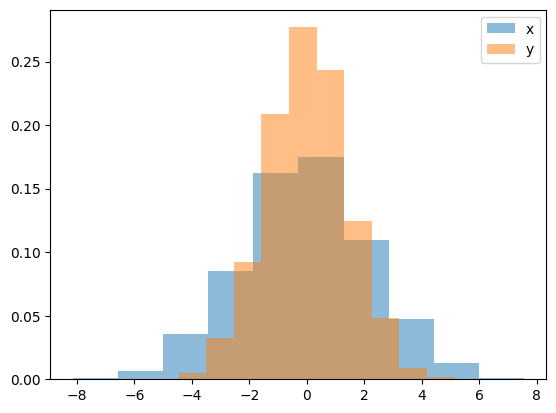

In [45]:
for col in 'xy':
    plt.hist(data[col], density=True, alpha=0.5, label=col)
plt.legend()    

Still using `plt.hist()` with a larger number of bins (30).  

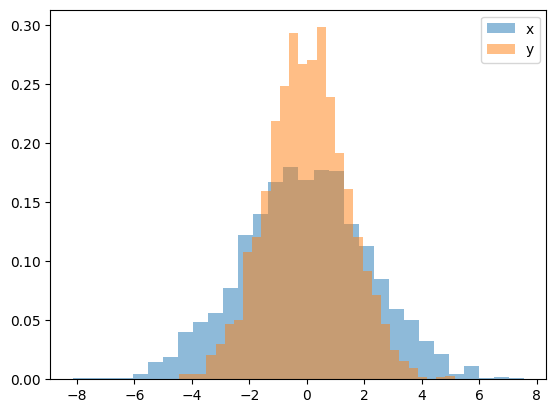

In [47]:
for col in 'xy':
    plt.hist(data[col], density=True, alpha=0.5, bins=30, label=col)
plt.legend()    

Now let's plot the same histogram with the same code less  `density`. Note that the `y` axis is now count. The differences between with and without density shows that `density` smooths out the plot with probability functions.

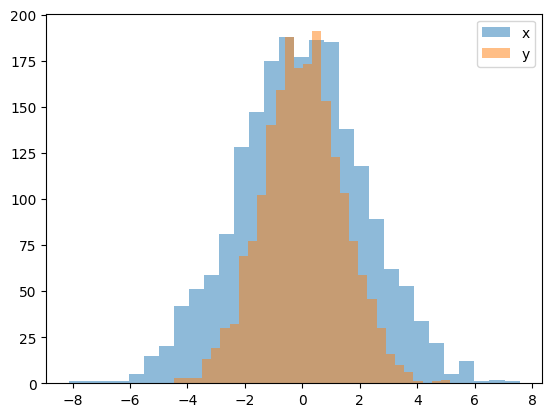

In [49]:
for col in 'xy':
    plt.hist(data[col], alpha=0.5, bins=30, label=col)
plt.legend()    

Now let's use Seaborn's `histplot()` to plot column `x` and then `y`.

<Axes: xlabel='x', ylabel='Count'>

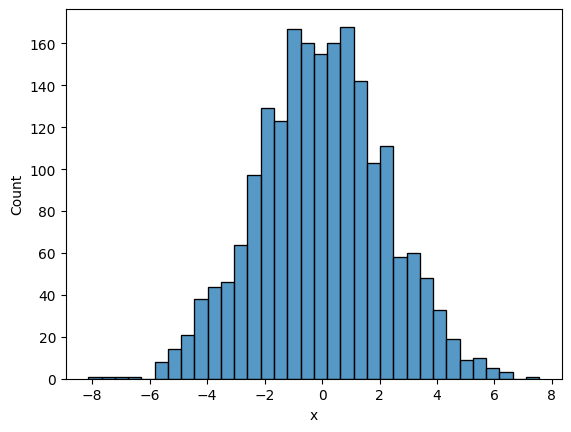

In [40]:
sns.histplot(x='x', data=data, alpha=0.75)

<Axes: xlabel='y', ylabel='Count'>

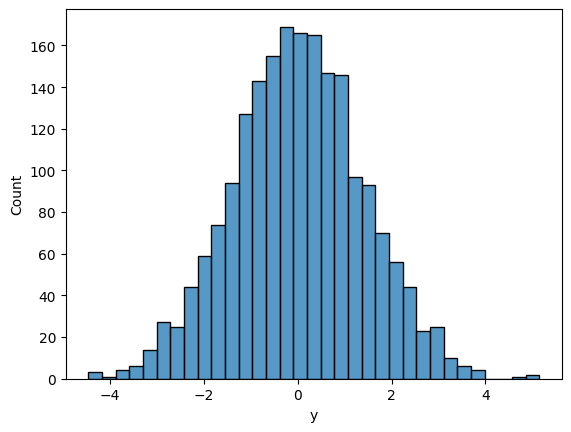

In [ ]:
sns.histplot(x='y', data=data, alpha=0.75)

With the same code, we are plotting `x` and `y` columns using `sns.histplot` instead of `plt.hist()`.

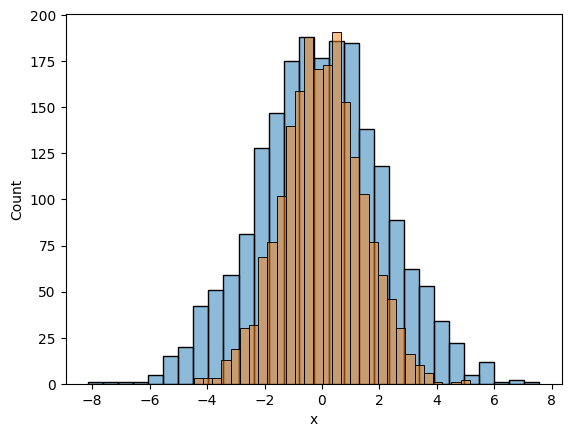

In [54]:
for col in 'xy':
    # sns.histplot(data[col], alpha=0.5, bins=30, kde=True)     ### seaborn
    sns.histplot(data[col], alpha=0.5, bins=30)                 ### seaborn

We can also add `kde=True` to show the KDE plot.

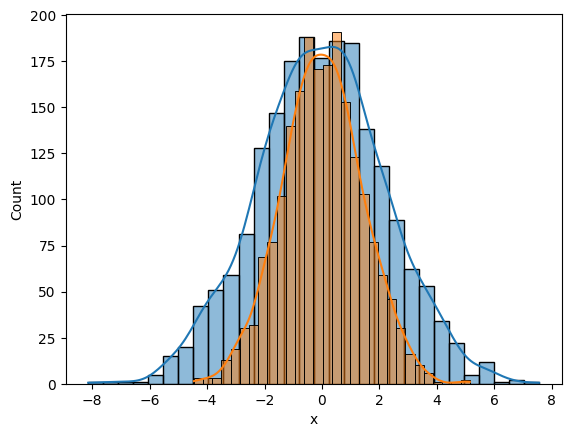

In [55]:
for col in 'xy':
    sns.histplot(data[col], alpha=0.5, bins=30, kde=True)     ### seaborn
    # sns.histplot(data[col], alpha=0.5, bins=30)                 ### seaborn

Histograms are useful, but sometimes we want a smoother representation of our data's distribution. We can achieve this using kernel density estimation (KDE), which creates a continuous curve instead of bins. In Seaborn, use `sns.kdeplot()` to create a KDE plot.

## KDE Plot

<Axes: ylabel='Density'>

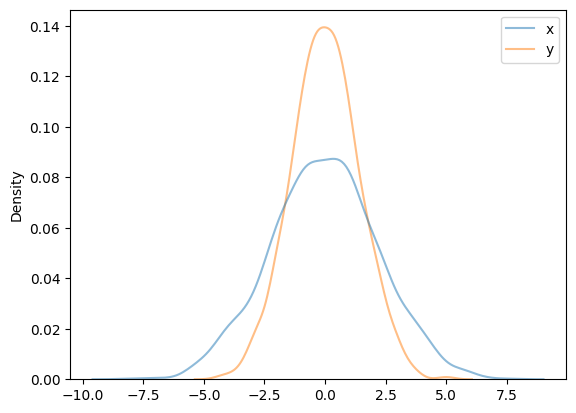

In [37]:
### by default, line plot

# sns.kdeplot(data=data, fill=True, alpha=0.5)
sns.kdeplot(data=data, alpha=0.5)

If we pass x and y columns to kdeplot, we instead get a two-dimensional visualization
of the joint density:

## Density Plot
A density plot is any chart showing an estimate of a distribution (probability density), while a KDE plot is one specific kind of density plot that uses a Kernel Density Estimate (a smooth, nonparametric estimator).

<Axes: xlabel='x', ylabel='y'>

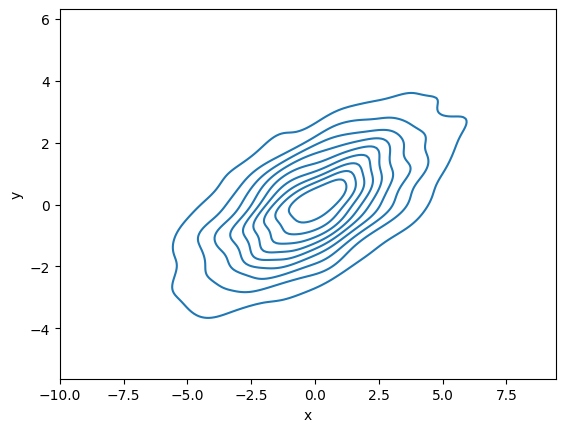

In [ ]:
### kde plot with x and y

sns.kdeplot(data=data, x='x', y='y')

While we are looking at distributions, let's try to plot a scatter plot.

## Scatter Plot

<Axes: xlabel='x', ylabel='y'>

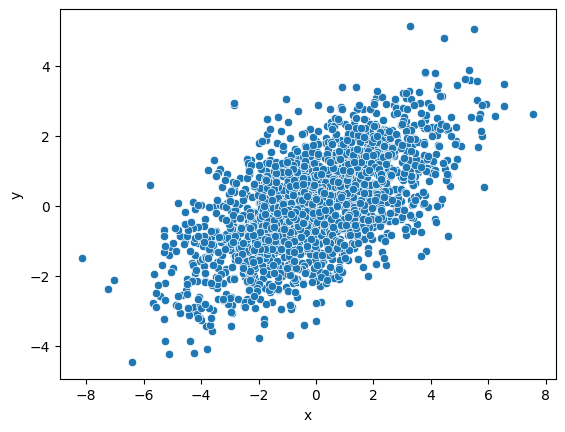

In [25]:
### use: https://seaborn.pydata.org/ to figure this out

sns.scatterplot(x='x', y='y', data=data)

## Pair Plot

Pair plots take the concept of joint plots one step further by visualizing relationships between all pairs of variables in a dataset. Instead of creating plots one by one, a pair plot generates an entire grid automatically—perfect for exploring multidimensional data.
We'll use the famous Iris dataset to demonstrate. This dataset contains measurements of petal length, petal width, sepal length, and sepal width for three different iris species:

To visualize all the relationships between variables, simply use **`sns.pairplot()`**:


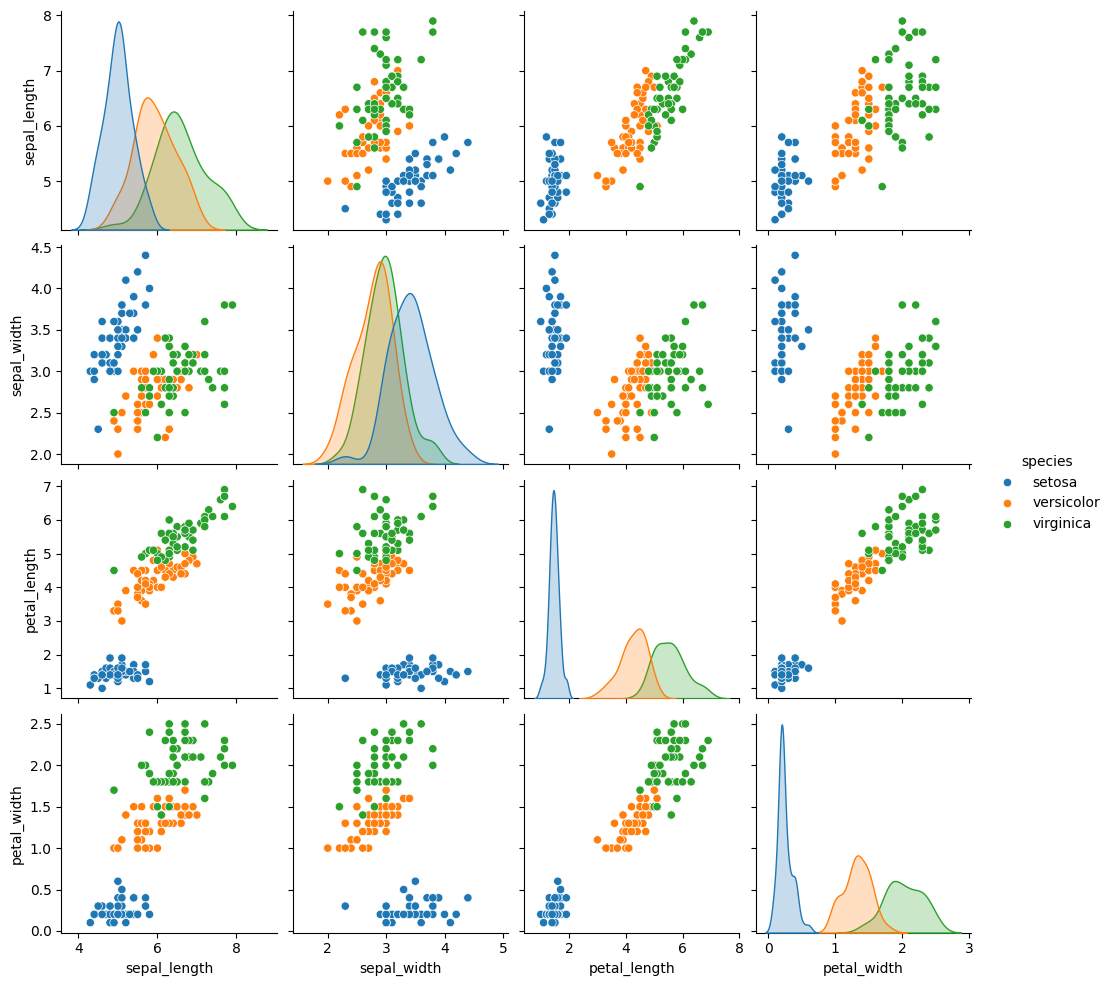

In [ ]:
sns.pairplot(iris, hue='species', height=2.5)

## Categorical Plots

`sns.catplot()` is a wrapper for several plot types. `catplot()` can create different kinds of categorical plots using the kind argument:

| kind       | Description                              | Example use                       |
| ---------- | ---------------------------------------- | --------------------------------- |
| `"strip"`  | scatter points for each category         | show raw data distribution        |
| `"swarm"`  | scatter points adjusted to avoid overlap | show each observation clearly     |
| `"box"`    | **box plot**                             | show **median, quartiles, outliers**  |
| `"violin"` | smoothed version of box plot             | show full data distribution shape |
| `"boxen"`  | enhanced box plot for large datasets     | detailed distribution             |
| `"point"`  | shows mean and confidence interval       | highlight summary trends          |
| `"bar"`    | **bar heights** = **mean** value per category    | **compare averages**                  |
| `"count"`  | bar chart of counts per category         | visualize frequency               |


Categorical plots provide another way to visualize these relationships. With categorical plots, you can see how values of one variable (like total bill amount) are distributed within categories of another variable (like day of the week), as shown in:

### Box Plot

| Element                    | Meaning                                                                                                         |
| -------------------------- | --------------------------------------------------------------------------------------------------------------- |
| **Box**                    | The middle 50% of the data (from 25th to 75th percentile, or Q1 to Q3): the *interquartile range (IQR = Q3-Q1)* |
| **Line inside box**        | The **median** (50th percentile)                                                                                |
| **Whiskers**               | Extend from the box to show data within 1.5 × IQR of Q1 and Q3                                                  |
| **Points beyond whiskers** | These are **outliers** — values that fall far outside the main range (Q1-1.5IQR, Q3 + 1.5IQR)                                            |


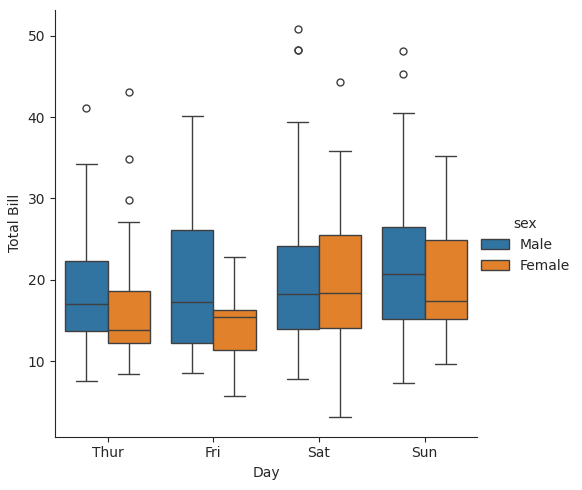

In [ ]:
### with sns.axes_style(style='ticks'):
### means temporarily changes the plot’s visual style inside the with block
### sns.axes_style() controls background elements like gridlines, ticks, and axis spines.
### "ticks" is a style

with sns.axes_style(style='ticks'):     ### use 'ticks' style in this with block
    g = sns.catplot(x="day", y="total_bill", hue="sex", data=tips, kind="box")
    g.set_axis_labels("Day", "Total Bill")

### Bar Plot

(compare with `sns.barplot()` later)

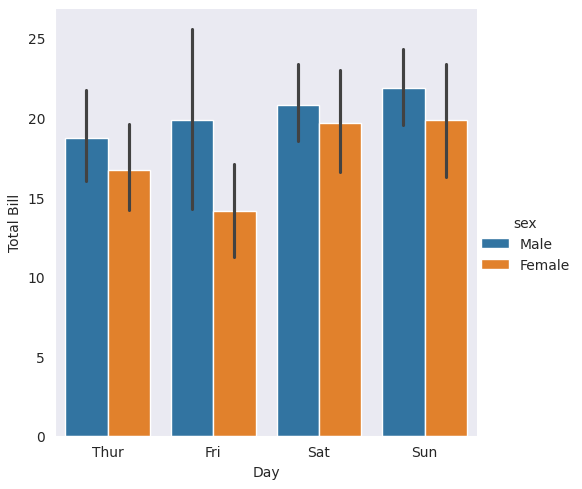

In [ ]:
### black vertical lines are confidence intervals (95% by default)

with sns.axes_style(style='dark'):     
    g = sns.catplot(x="day", y="total_bill", hue="sex", data=tips, kind="bar")
    g.set_axis_labels("Day", "Total Bill")

## Bar Plots



In [ ]:
planets = sns.load_dataset('planets')
planets.head

<bound method NDFrame.head of                method  number  orbital_period   mass  distance  year
0     Radial Velocity       1      269.300000   7.10     77.40  2006
1     Radial Velocity       1      874.774000   2.21     56.95  2008
2     Radial Velocity       1      763.000000   2.60     19.84  2011
3     Radial Velocity       1      326.030000  19.40    110.62  2007
4     Radial Velocity       1      516.220000  10.50    119.47  2009
...               ...     ...             ...    ...       ...   ...
1030          Transit       1        3.941507    NaN    172.00  2006
1031          Transit       1        2.615864    NaN    148.00  2007
1032          Transit       1        3.191524    NaN    174.00  2007
1033          Transit       1        4.125083    NaN    293.00  2008
1034          Transit       1        4.187757    NaN    260.00  2008

[1035 rows x 6 columns]>

## Bar Plots

We'll plot a bar chart with the `planets` dataset, another built-in dataset of Seaborn.


In [ ]:
planets = sns.load_dataset('planets')
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [ ]:
print(type(planets))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
planets

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008


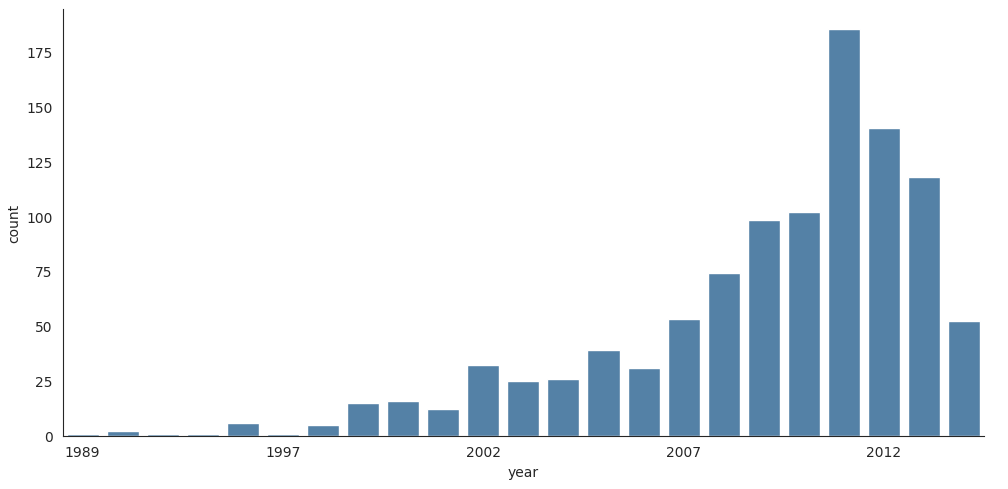

In [ ]:
with sns.axes_style('white'):
    g = sns.catplot(
        x='year',
        data=planets,
        aspect=2,
        kind='count',
        color='steelblue'
    )
    g.set_xticklabels(step=5)

## Joint Plots

Like the pair plots we saw earlier, **sns.jointplot()** visualizes the relationship between two variables. However, instead of showing all pairwise relationships, a joint plot focuses on a single pair, displaying both how the variables relate to each other (in the center) and how each variable is distributed individually (along the edges). 

Beyond scatter plots, joint plots can automatically overlay kernel density estimates (to show smooth distributions) and **regression lines** (to highlight trends):

### Hex

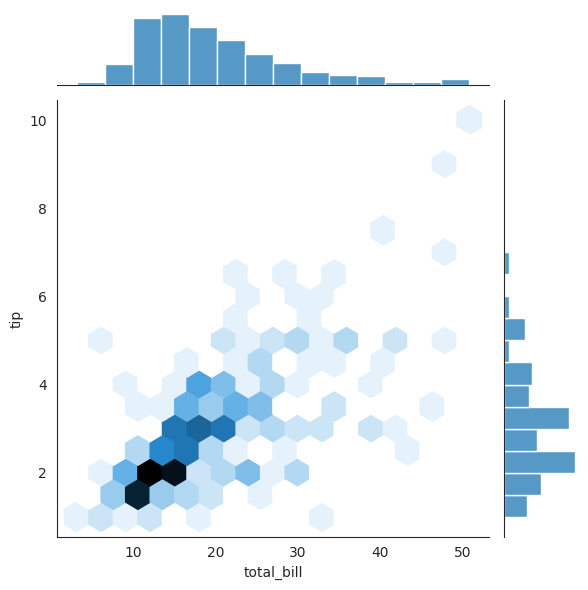

In [ ]:
with sns.axes_style('white'):
    sns.jointplot(x="total_bill", y="tip", data=tips, kind='hex')   ### try different kind

### Regression

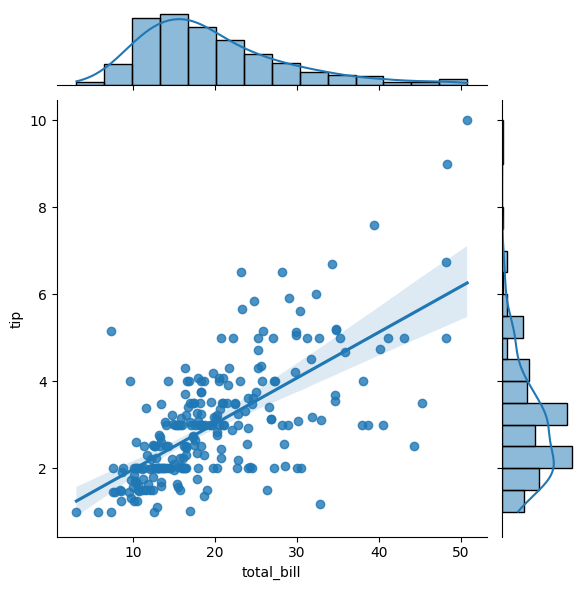

In [ ]:
sns.jointplot(x="total_bill", y="tip", data=tips, kind='reg')

## Faceted Histograms

When comparing multiple groups, side-by-side histograms can reveal patterns that might be hidden in a single plot. Seaborn's FacetGrid allows us to create these comparison plots effortlessly. Let's use a restaurant tipping dataset to see how tip amounts vary across different categories:

In [67]:
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']   ### create a new column

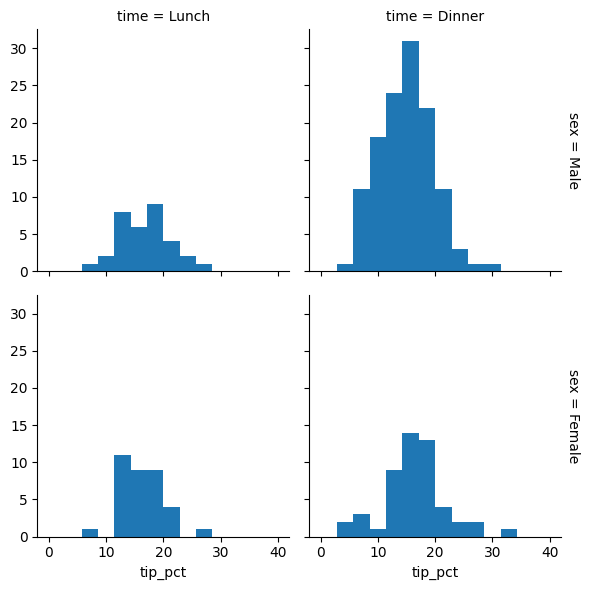

In [71]:
grid = sns.FacetGrid(data=tips, row="sex", col="time", margin_titles=True)
grid.map(plt.hist, "tip_pct", bins=np.linspace(0, 40, 15))   ### apply .hist to column "tip_pct"